In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np

# Crear un DataFrame de ejemplo con errores y datos faltantes
data = {
    "Nombre": ["Ana", "Luis", "Carlos", "Marta", None, "Sofía", "Juan"],
    "Edad": [25, 30, -1, None, 45, 0, 28],
    "Ciudad": ["Santiago", "Valparaíso", None, "Concepción", "Santiago", None, "Antofagasta"],
    "Genero": ["F", "M", "M", "F", None, "F", "M"]
}

df = pd.DataFrame(data)
print("DataFrame original con errores y nulos:\n")
print(df)


DataFrame original con errores y nulos:

   Nombre  Edad       Ciudad Genero
0     Ana  25.0     Santiago      F
1    Luis  30.0   Valparaíso      M
2  Carlos  -1.0         None      M
3   Marta   NaN   Concepción      F
4    None  45.0     Santiago   None
5   Sofía   0.0         None      F
6    Juan  28.0  Antofagasta      M


In [ ]:
#  1. Detección de datos faltantes
print("\n¿Dónde hay valores nulos (NaN)? Usamos .isna() o .isnull():")
print(df.isna())
# ¿Qué hace df.isna()?
# Devuelve otro DataFrame del mismo tamaño, pero con valores booleanos:
# True significa que el valor en esa celda es nulo (NaN).
# False significa que no está nulo, o sea, tiene un dato válido.


¿Dónde hay valores nulos (NaN)? Usamos .isna() o .isnull():
   Nombre   Edad  Ciudad  Genero
0   False  False   False   False
1   False  False   False   False
2   False  False    True   False
3   False   True   False   False
4    True  False   False    True
5   False  False    True   False
6   False  False   False   False


In [ ]:
# 2. Conteo de valores faltantes por columna
print("\nConteo de nulos por columna:")
print(df.isnull().sum())


Conteo de nulos por columna:
Nombre    1
Edad      1
Ciudad    2
Genero    1
dtype: int64


In [ ]:
# 3. Rellenar valores faltantes con fillna()
print("\n Rellenar valores faltantes en 'Ciudad' con 'Desconocido':")
df["Ciudad"] = df["Ciudad"].fillna("Desconocido")
print(df)


 Rellenar valores faltantes en 'Ciudad' con 'Desconocido':
   Nombre  Edad       Ciudad Genero
0     Ana  25.0     Santiago      F
1    Luis  30.0   Valparaíso      M
2  Carlos  -1.0  Desconocido      M
3   Marta   NaN   Concepción      F
4    None  45.0     Santiago   None
5   Sofía   0.0  Desconocido      F
6    Juan  28.0  Antofagasta      M


In [ ]:
#  4. Eliminar filas con nulos usando dropna()
print("\n Eliminar filas donde faltan datos en la columna 'Nombre':")
df_limpio = df.dropna(subset=["Nombre"])
print(df_limpio)



 Eliminar filas donde faltan datos en la columna 'Nombre':
   Nombre  Edad       Ciudad Genero
0     Ana  25.0     Santiago      F
1    Luis  30.0   Valparaíso      M
2  Carlos  -1.0  Desconocido      M
3   Marta   NaN   Concepción      F
5   Sofía   0.0  Desconocido      F
6    Juan  28.0  Antofagasta      M


In [ ]:
#  5. Reemplazar valores incorrectos con replace()
print("\n Reemplazar edades negativas o igual a cero por la media de edades válidas:")
edades_validas = df["Edad"][df["Edad"] > 0]
media_edad = edades_validas.mean()
df["Edad"] = df["Edad"].apply(lambda x: media_edad if pd.isna(x) or x <= 0 else x)
print(df)
# Reemplaza cada valor de la columna Edad según esta condición:
# Si x es NaN (pd.isna(x)) o menor o igual que 0 (x <= 0), entonces se reemplaza por media_edad (32.0).
# Si x es válido (> 0), se deja igual.



 Reemplazar edades negativas o igual a cero por la media de edades válidas:
   Nombre  Edad       Ciudad Genero
0     Ana  25.0     Santiago      F
1    Luis  30.0   Valparaíso      M
2  Carlos  32.0  Desconocido      M
3   Marta  32.0   Concepción      F
4    None  45.0     Santiago   None
5   Sofía  32.0  Desconocido      F
6    Juan  28.0  Antofagasta      M


In [ ]:
#  6. Filtrado condicional
print("\n Filtrar personas mayores de 30 años:")
print(df[df["Edad"] > 30])


 Filtrar personas mayores de 30 años:
   Nombre  Edad       Ciudad Genero
2  Carlos  32.0  Desconocido      M
3   Marta  32.0   Concepción      F
4    None  45.0     Santiago   None
5   Sofía  32.0  Desconocido      F


In [ ]:
#  7. Estadísticas descriptivas
print("\n Estadísticas con describe():")
print(df.describe(include="all"))



 Estadísticas con describe():
       Nombre       Edad    Ciudad Genero
count       6   7.000000         7      6
unique      6        NaN         5      2
top       Ana        NaN  Santiago      F
freq        1        NaN         2      3
mean      NaN  32.000000       NaN    NaN
std       NaN   6.298148       NaN    NaN
min       NaN  25.000000       NaN    NaN
25%       NaN  29.000000       NaN    NaN
50%       NaN  32.000000       NaN    NaN
75%       NaN  32.000000       NaN    NaN
max       NaN  45.000000       NaN    NaN


In [ ]:
#  8. Conteo de frecuencias con value_counts()
print("\n Conteo de personas por ciudad:")
print(df["Ciudad"].value_counts())


 Conteo de personas por ciudad:
Ciudad
Santiago       2
Desconocido    2
Valparaíso     1
Concepción     1
Antofagasta    1
Name: count, dtype: int64


In [ ]:
#  9. Detección de no-nulos con notna()
print("\n ¿Qué valores NO son nulos en la columna 'Genero'?")
print(df["Genero"].notna())
# .notna() es un método de Pandas que devuelve True si el valor no es nulo (NaN) y False si el valor es nulo.
# Funciona fila por fila sobre una Serie o DataFrame.


 ¿Qué valores NO son nulos en la columna 'Genero'?
0     True
1     True
2     True
3     True
4    False
5     True
6     True
Name: Genero, dtype: bool


In [ ]:
#  10. Exportar el DataFrame limpio a Excel o CSV
df.to_csv("datos_limpios.csv", index=False)
print("\n Datos exportados a 'datos_limpios.csv'")


 Datos exportados a 'datos_limpios.csv'


In [ ]:
# En Google Colab, puedes descargar así:
from google.colab import files
files.download("datos_limpios.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Actividad Avanzada: Limpieza y análisis de datos reales con valores faltantes
Objetivo:
Aplicar técnicas de detección, conteo, imputación y visualización de datos faltantes sobre un conjunto real. Aprender a tomar decisiones informadas sobre cómo tratar los valores faltantes.

In [ ]:
#  Paso 1: Cargar un conjunto de datos con valores faltantes
# Cargar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Leer un conjunto de datos con valores faltantes
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
print("Primeras filas del DataFrame original:")
print(df.head())

Primeras filas del DataFrame original:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# Paso 2: Detección y conteo de valores faltantes (NaN)
# ¿Dónde hay nulos?
print("\n¿Dónde hay valores nulos?")
print(df.isna())

# Conteo por columna
print("\nConteo de nulos por columna:")
print(df.isnull().sum())

# Ver el porcentaje de valores faltantes por columna
print("\nPorcentaje de valores nulos:")
print((df.isnull().mean() * 100).round(2))


¿Dónde hay valores nulos?
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     DiabetesPedigreeFunction    Age  Outcome  
0                       

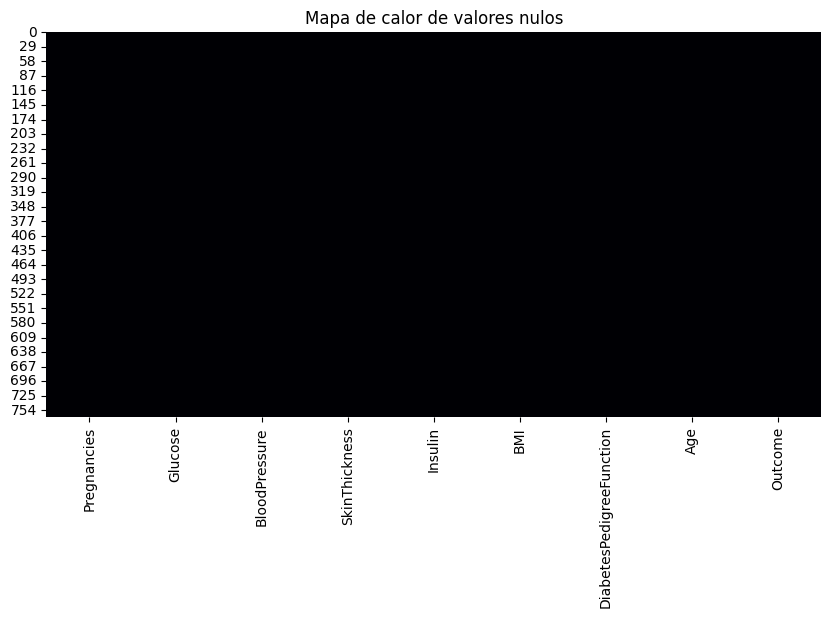

In [ ]:
# Paso 3: Visualización de los valores faltantes
# Visualización con mapa de calor
plt.figure(figsize=(10,5))  # Define el tamaño del gráfico
sns.heatmap(df.isnull(), cbar=False, cmap='magma')  # Crea el mapa de calor con la paleta "magma"
plt.title("Mapa de calor de valores nulos") # Agrega título
plt.show() # # Muestra el gráfico
# El código genera un mapa de calor (heatmap) para visualizar los valores nulos en el DataFrame. Como el
# gráfico es completamente oscuro (sin colores diferentes), significa que no hay valores nulos en ninguna celda.
# f.isnull() crea una matriz booleana: True si hay nulo, False si no.

# sns.heatmap() visualiza esa matriz; los True se ven como zonas de color (normalmente amarillo/blanco), los False como negro o colores oscuros.

# Como todo es negro, eso confirma visualmente que no hay NaN

In [ ]:
# Actividad: Tratamiento de valores faltantes en un DataFrame

# Paso 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Paso 2: Crear un DataFrame de ejemplo con datos faltantes
data = {
    "Nombre": ["Ana", "Luis", "Carlos", "Marta", None, "Sofía", "Juan", "Laura"],
    "Edad": [25, 30, np.nan, 45, 50, np.nan, 28, 40],
    "Ciudad": ["Santiago", "Valparaíso", None, "Concepción", "Santiago", "Iquique", None, "Temuco"],
    "Genero": ["F", "M", "M", "F", None, "F", "M", None],
    "Ingreso": [3000, 4000, 3500, np.nan, 5000, 2800, np.nan, 4100]
}

df = pd.DataFrame(data)
print("DataFrame original con errores y nulos:\n")
print(df)

DataFrame original con errores y nulos:

   Nombre  Edad      Ciudad Genero  Ingreso
0     Ana  25.0    Santiago      F   3000.0
1    Luis  30.0  Valparaíso      M   4000.0
2  Carlos   NaN        None      M   3500.0
3   Marta  45.0  Concepción      F      NaN
4    None  50.0    Santiago   None   5000.0
5   Sofía   NaN     Iquique      F   2800.0
6    Juan  28.0        None      M      NaN
7   Laura  40.0      Temuco   None   4100.0


In [ ]:
# Paso 3: Detección de valores faltantes
print("\n¿Dónde hay valores nulos?")
print(df.isnull())


¿Dónde hay valores nulos?
   Nombre   Edad  Ciudad  Genero  Ingreso
0   False  False   False   False    False
1   False  False   False   False    False
2   False   True    True   False    False
3   False  False   False   False     True
4    True  False   False    True    False
5   False   True   False   False    False
6   False  False    True   False     True
7   False  False   False    True    False


In [ ]:
# Paso 4: Conteo y porcentaje de nulos por columna
print("\nConteo de nulos por columna:")
print(df.isnull().sum())

print("\nPorcentaje de nulos por columna:")
print(df.isnull().mean() * 100)


Conteo de nulos por columna:
Nombre     1
Edad       2
Ciudad     2
Genero     2
Ingreso    2
dtype: int64

Porcentaje de nulos por columna:
Nombre     12.5
Edad       25.0
Ciudad     25.0
Genero     25.0
Ingreso    25.0
dtype: float64


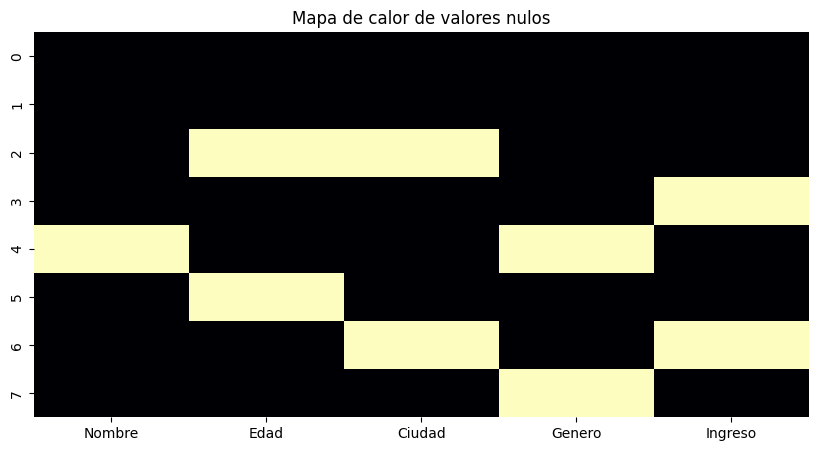

In [ ]:
# Paso 5: Visualización con heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=True)
plt.title("Mapa de calor de valores nulos")
plt.show()

In [ ]:
# Paso 6: Imputar valores
# Imputar edad con la media
df["Edad"] = df["Edad"].fillna(df["Edad"].mean())
# Imputar ciudad con "Desconocido"
df["Ciudad"] = df["Ciudad"].fillna("Desconocido")

# Imputar género con moda
df["Genero"] = df["Genero"].fillna(df["Genero"].mode()[0])

# Imputar ingreso con un valor constante
df["Ingreso"] = df["Ingreso"].fillna(0)

# Rellenar valores faltantes en 'Nombre'
df["Nombre"] = df["Nombre"].fillna("SinNombre")

print("\nDataFrame luego de imputaciones:\n")
print(df)


DataFrame luego de imputaciones:

      Nombre       Edad       Ciudad Genero  Ingreso
0        Ana  25.000000     Santiago      F   3000.0
1       Luis  30.000000   Valparaíso      M   4000.0
2     Carlos  36.333333  Desconocido      M   3500.0
3      Marta  45.000000   Concepción      F      0.0
4  SinNombre  50.000000     Santiago      F   5000.0
5      Sofía  36.333333      Iquique      F   2800.0
6       Juan  28.000000  Desconocido      M      0.0
7      Laura  40.000000       Temuco      F   4100.0


In [ ]:
# Paso 7: Eliminar filas si es necesario (ya no hace falta aquí porque se imputó)
# df.dropna(inplace=True)

In [ ]:
# Paso 8: Exportar resultados
df.to_excel("datos_limpios.xlsx", index=False)
df.to_csv("datos_limpios.csv", index=False)
# Descargar archivos en Colab
from google.colab import files
files.download("datos_limpios.xlsx")
files.download("datos_limpios.csv")

# Explicación de los cambios:
# Edad: se imputaron los valores faltantes con el promedio, que fue 36.33.

# Ciudad: se reemplazaron valores faltantes con "Desconocido".

# Genero: se imputó el valor faltante con la moda, que fue 'F'.

# Ingreso: los valores NaN fueron reemplazados con 0.0.

# Nombre: no fue imputado, por eso aparece un registro con None

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Datos de ejemplo con valores atípicos
df = pd.DataFrame({
    "Edad": [25, 30, 28, 35, 40, 100, 26, 27, 24, 120]
})

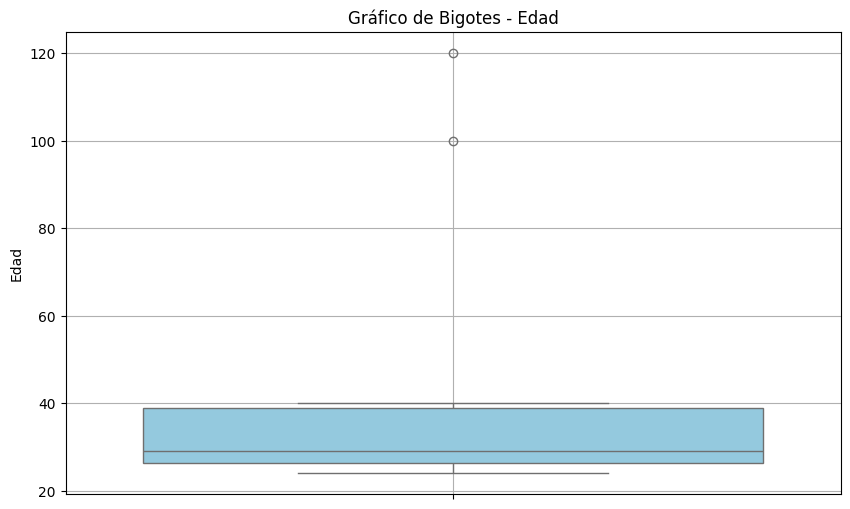

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y="Edad", color="skyblue")
plt.title("Gráfico de Bigotes - Edad")
plt.ylabel("Edad")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Crear un DataFrame con valores atípicos y faltantes
df = pd.DataFrame({
    "Edad": [25, 30, 28, 35, 40, 100, 26, np.nan, 24, 120]
})

print("Datos originales:")
print(df)

# Calcular IQR
Q1 = df["Edad"].quantile(0.25)
Q3 = df["Edad"].quantile(0.75)
IQR = Q3 - Q1

# Rango aceptable
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("\nQ1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Límites aceptables:", limite_inferior, "a", limite_superior)

# OPCIÓN 1: Reemplazar valores fuera de rango por la mediana (o por el límite)
mediana = df["Edad"].median()
df["Edad_IQR"] = df["Edad"].apply(lambda x: mediana if x < limite_inferior or x > limite_superior else x)

# OPCIÓN 2: Reemplazar valores faltantes (NaN) por mediana
df["Edad_IQR"] = df["Edad_IQR"].fillna(mediana)

print("\nDataFrame con imputación por IQR:")
print(df)

Datos originales:
    Edad
0   25.0
1   30.0
2   28.0
3   35.0
4   40.0
5  100.0
6   26.0
7    NaN
8   24.0
9  120.0

Q1: 26.0 Q3: 40.0 IQR: 14.0
Límites aceptables: 5.0 a 61.0

DataFrame con imputación por IQR:
    Edad  Edad_IQR
0   25.0      25.0
1   30.0      30.0
2   28.0      28.0
3   35.0      35.0
4   40.0      40.0
5  100.0      30.0
6   26.0      26.0
7    NaN      30.0
8   24.0      24.0
9  120.0      30.0


In [ ]:
# Alternativa: marcar outliers y luego imputar
# Marcar los outliers
df["es_outlier"] = (df["Edad"] < limite_inferior) | (df["Edad"] > limite_superior)

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np

Actividad a realizar:
importar pandas, seaborn y matplotlib.

1. Cargar el dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
2. Detectar valores faltantes
3. Visualizar nulos
4. Limpieza del dataset
5. Imputa age utilizando la mediana.
6. Imputa embarked y embark_town con la moda (valor más frecuente).
7. Decide sobre deck:
Si quieres conservarla, rellena los nulos con "Unknown" (implica alto porcentaje).
Si prefieres eliminarla, usa df.drop(columns=['deck'], inplace=True).

8. Verificar valores nulos después de la limpeza.

9. Comparación estadística de antes y después de la limpieza.

10. Filtra todas las filas donde el pasajero sea mujer (sex == "female") y tenga más de 30 años. Muestra solo las columnas sex, age y fare.

11. Pregunta 2: Frecuencia con .value_counts()
¿Cuál es la frecuencia de cada clase de pasajero (pclass) en el dataset? Usa value_counts()

12. Hallazgos y discusión

¿Ayuda la imputación a mejorar la calidad del dataset?

¿Qué implicaciones tiene eliminar columnas con alto porcentaje de nulos?

¿Es preferible imputar o eliminar filas?



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
